# Tema A · Tasas de Interés

**Curso: Matemáticas Financieras** — Notebook de aplicación práctica

Este notebook cubre el **Tema A del temario** (*Tasas de interés*) y traduce la teoría de la
presentación del curso en herramientas de Python que puedes reutilizar en análisis
empresarial y de inversiones:

- **A.I** ¿Qué es una tasa de interés?
- **A.II** Riesgos que componen una tasa de interés (construcción de la tasa)
- **A.III** Tasa efectiva
- **A.IV** Tasa real
- **A.V** Tasa nominal

> Objetivo: que puedas construir, convertir y comparar tasas de interés para tomar
> decisiones de financiamiento e inversión, no solo resolver ejercicios de clase.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


## A.II — Construcción de una tasa de interés

Toda tasa de interés observada en el mercado puede descomponerse en:

$$
r = \text{Tasa real libre de riesgo} + \text{Premio a la inflación} + \text{Premio por riesgo de crédito}
+ \text{Premio por riesgo de liquidez} + \text{Premio al tiempo (plazo)}
$$

- **Tasa real libre de riesgo**: retorno de un instrumento sin riesgo de default ni de
  reinversión, sin considerar inflación.
- **Riesgo de default**: probabilidad de que la contraparte no cumpla sus obligaciones.
- **Riesgo de reinversión**: posibilidad de no poder reinvertir los flujos a una tasa
  comparable a la actual.
- **Premio a la inflación**, **premio por riesgo de crédito**, **premio por riesgo de
  liquidez** y **premio al plazo (vencimiento)** compensan al inversionista por cada
  fuente de riesgo adicional.

Esta descomposición es exactamente lo que hace un analista de crédito o un tesorero de
empresa cuando cotiza una tasa para un crédito corporativo o cuando construye una tasa
de descuento para valuar un proyecto.


In [2]:
def construir_tasa_interes(tasa_real_libre_riesgo, premio_inflacion,
                            premio_riesgo_credito=0.0, premio_riesgo_liquidez=0.0,
                            premio_plazo=0.0):
    '''Construye una tasa de interés nominal a partir de sus componentes (suma simple,
    tal como se presenta en el curso).

    Parámetros en tasas decimales (p.ej. 3% -> 0.03).
    Regresa un diccionario con cada componente y la tasa total.
    '''
    componentes = {
        "Tasa real libre de riesgo": tasa_real_libre_riesgo,
        "Premio a la inflación": premio_inflacion,
        "Premio por riesgo de crédito": premio_riesgo_credito,
        "Premio por riesgo de liquidez": premio_riesgo_liquidez,
        "Premio al plazo": premio_plazo,
    }
    tasa_total = sum(componentes.values())
    componentes["Tasa nominal resultante"] = tasa_total
    return componentes


# Ejemplo: crédito corporativo a una empresa mediana, a 5 años, en un mercado emergente
componentes = construir_tasa_interes(
    tasa_real_libre_riesgo=0.02,   # 2%
    premio_inflacion=0.045,        # 4.5%
    premio_riesgo_credito=0.025,   # 2.5% por riesgo de la empresa (BB)
    premio_riesgo_liquidez=0.008,  # 0.8% por baja bursatilidad del instrumento
    premio_plazo=0.012,            # 1.2% por el plazo a 5 años
)

df_componentes = pd.DataFrame(componentes.items(), columns=["Componente", "Valor"])
df_componentes["Valor (%)"] = (df_componentes["Valor"] * 100).round(3)
df_componentes


,Componente,Valor,Valor (%)
0,Tasa real libre de riesgo,0.020000,2.000000
1,Premio a la inflación,0.045000,4.500000
2,Premio por riesgo de crédito,0.025000,2.500000
3,Premio por riesgo de liquidez,0.008000,0.800000
4,Premio al plazo,0.012000,1.200000
5,Tasa nominal resultante,0.110000,11.000000


### Caso empresarial: cotizar una tasa de crédito

Un tesorero puede usar `construir_tasa_interes` como una **calculadora de pricing**: al
variar el premio por riesgo de crédito (según el rating de la contraparte) o el premio
por plazo, se obtiene rápidamente la tasa nominal que la empresa debería cobrar o pagar,
manteniendo trazabilidad de cada componente para negociar con el cliente o el banco.


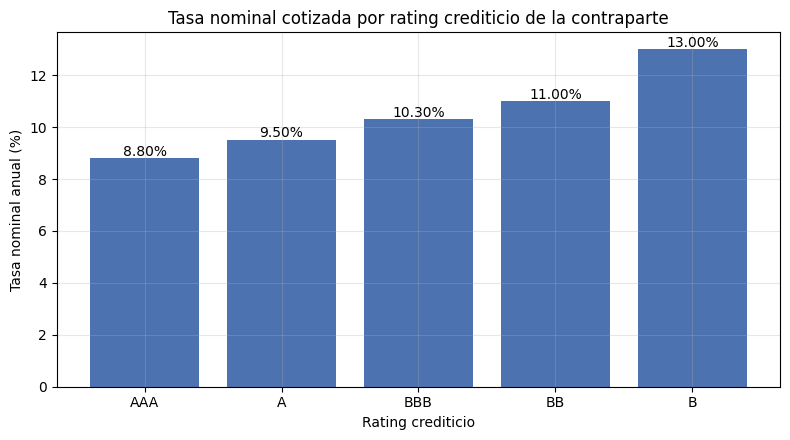

,Rating,Premio crédito,Tasa nominal,Tasa nominal (%)
0,AAA,0.003000,0.088000,8.800000
1,A,0.010000,0.095000,9.500000
2,BBB,0.018000,0.103000,10.300000
3,BB,0.025000,0.110000,11.000000
4,B,0.045000,0.130000,13.000000


In [3]:
def sensibilidad_rating(tasa_real, inflacion, premio_liquidez, premio_plazo, premios_credito: dict):
    '''Compara la tasa nominal resultante para distintos ratings crediticios.'''
    filas = []
    for rating, premio_credito in premios_credito.items():
        c = construir_tasa_interes(tasa_real, inflacion, premio_credito, premio_liquidez, premio_plazo)
        filas.append({"Rating": rating, "Premio crédito": premio_credito,
                       "Tasa nominal": c["Tasa nominal resultante"]})
    return pd.DataFrame(filas)

premios_por_rating = {"AAA": 0.003, "A": 0.010, "BBB": 0.018, "BB": 0.025, "B": 0.045}
tabla_rating = sensibilidad_rating(0.02, 0.045, 0.008, 0.012, premios_por_rating)
tabla_rating["Tasa nominal (%)"] = (tabla_rating["Tasa nominal"] * 100).round(2)

fig, ax = plt.subplots()
ax.bar(tabla_rating["Rating"], tabla_rating["Tasa nominal (%)"], color="#4C72B0")
ax.set_title("Tasa nominal cotizada por rating crediticio de la contraparte")
ax.set_ylabel("Tasa nominal anual (%)")
ax.set_xlabel("Rating crediticio")
for i, v in enumerate(tabla_rating["Tasa nominal (%)"]):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.show()

tabla_rating


## A.IV — Tasa real, tasa nominal y la Ecuación de Fisher

La **ecuación de Fisher** relaciona la tasa nominal $i$, la tasa real $r$ y la inflación
$\pi$:

$$
(1+i) = (1+r)(1+\pi) \qquad\Longrightarrow\qquad r = \frac{1+i}{1+\pi} - 1
$$

Una aproximación muy usada (válida para tasas e inflación bajas) es:

$$
r \approx i - \pi
$$


In [4]:
def tasa_real_exacta(tasa_nominal, inflacion):
    '''Ecuación de Fisher exacta: r = (1+i)/(1+pi) - 1'''
    return (1 + tasa_nominal) / (1 + inflacion) - 1


def tasa_real_aproximada(tasa_nominal, inflacion):
    '''Aproximación r ~= i - pi (subestima/sobreestima la tasa real)'''
    return tasa_nominal - inflacion


def tasa_nominal_exacta(tasa_real, inflacion):
    '''Despeje de Fisher: i = (1+r)(1+pi) - 1'''
    return (1 + tasa_real) * (1 + inflacion) - 1


### Ejercicio (slides): tasa real de un bono

> ¿Cuál será la tasa de interés real en una economía que tiene un rendimiento en bonos a
> un año del 6.5% si la inflación anual es del 4%?

Resultado esperado en las slides: aproximación **2.5%**, exacta **2.40%**.


In [5]:
i_bono = 0.065
inflacion = 0.04

r_aprox = tasa_real_aproximada(i_bono, inflacion)
r_exacta = tasa_real_exacta(i_bono, inflacion)

print(f"Tasa real aproximada (i - pi):     {r_aprox:.4%}")
print(f"Tasa real exacta (Fisher):         {r_exacta:.4%}")

assert round(r_aprox, 4) == 0.0250
assert round(r_exacta, 4) == 0.0240
print("\nOK: coincide con el ejercicio de las slides (2.50% aprox. / 2.40% exacta).")


Tasa real aproximada (i - pi):     2.5000%
Tasa real exacta (Fisher):         2.4038%

OK: coincide con el ejercicio de las slides (2.50% aprox. / 2.40% exacta).


### Aplicación en inversiones: ¿cuál instrumento conviene en términos reales?

Comparar tasas nominales entre países o instrumentos **sin ajustar por inflación** es un
error común. La función `tasa_real_exacta` permite comparar el rendimiento real de
distintas alternativas de inversión.


In [6]:
alternativas = pd.DataFrame({
    "Instrumento": ["CETES 28 días (MXN)", "T-Bill 4 semanas (USD)", "Bono corporativo local (MXN)"],
    "Tasa nominal": [0.1075, 0.0525, 0.1350],
    "Inflación esperada": [0.045, 0.028, 0.045],
})

alternativas["Tasa real (Fisher)"] = tasa_real_exacta(alternativas["Tasa nominal"], alternativas["Inflación esperada"])
alternativas_fmt = alternativas.copy()
for col in ["Tasa nominal", "Inflación esperada", "Tasa real (Fisher)"]:
    alternativas_fmt[col] = (alternativas_fmt[col] * 100).round(2)

mejor = alternativas.loc[alternativas["Tasa real (Fisher)"].idxmax(), "Instrumento"]
print(f"Mejor rendimiento REAL: {mejor}")
alternativas_fmt


Mejor rendimiento REAL: Bono corporativo local (MXN)


,Instrumento,Tasa nominal,Inflación esperada,Tasa real (Fisher)
0,CETES 28 días (MXN),10.750000,4.500000,5.980000
1,T-Bill 4 semanas (USD),5.250000,2.800000,2.380000
2,Bono corporativo local (MXN),13.500000,4.500000,8.610000


## A.III — Tasa de interés efectiva

La tasa efectiva es lo que **realmente** se gana o se paga al vencimiento, considerando
la periodicidad de capitalización.

$$
\text{Interés simple:}\quad i_r = i \cdot t \qquad\qquad
\text{Interés compuesto:}\quad i_r = (1+i)^t - 1
$$

Además, para adaptar una tasa anual a otra periodicidad de forma **proporcional simple**
(convención muy usada para cotizar tasas, no confundir con capitalización compuesta):

$$
i_{periodo} = \frac{i_{anual}}{m}
$$

donde $m$ es el número de periodos en un año (12 mensual, 6 bimestral, 4 trimestral, 3
cuatrimestral, 2 semestral).


In [7]:
def convertir_tasa_proporcional(tasa_anual, periodos_por_anio):
    '''Convierte una tasa anual a una tasa periódica proporcional simple (i/m).'''
    return tasa_anual / periodos_por_anio


def tasa_efectiva_simple(tasa_periodica, t_periodos):
    '''i_r = i * t (interés simple)'''
    return tasa_periodica * t_periodos


def tasa_efectiva_compuesta(tasa_periodica, t_periodos):
    '''i_r = (1+i)^t - 1 (interés compuesto)'''
    return (1 + tasa_periodica) ** t_periodos - 1


### Ejercicio (slides): tasas equivalentes a partir de una tasa anual del 27%


In [8]:
tasa_anual = 0.27
periodicidades = {"Mensual": 12, "Bimestral": 6, "Trimestral": 4, "Cuatrimestral": 3, "Semestral": 2}

tabla_periodicidad = pd.DataFrame({
    "Periodicidad": periodicidades.keys(),
    "m (periodos/año)": periodicidades.values(),
})
tabla_periodicidad["Tasa periódica"] = tabla_periodicidad["m (periodos/año)"].apply(
    lambda m: convertir_tasa_proporcional(tasa_anual, m)
)
tabla_periodicidad["Tasa periódica (%)"] = (tabla_periodicidad["Tasa periódica"] * 100).round(2)

esperado = {"Mensual": 2.25, "Bimestral": 4.50, "Trimestral": 6.75, "Cuatrimestral": 9.00, "Semestral": 13.5}
for _, fila in tabla_periodicidad.iterrows():
    assert abs(fila["Tasa periódica (%)"] - esperado[fila["Periodicidad"]]) < 0.01

print("OK: coincide con las slides (2.25%, 4.50%, 6.75%, 9.00%, 13.50%).")
tabla_periodicidad[["Periodicidad", "m (periodos/año)", "Tasa periódica (%)"]]


OK: coincide con las slides (2.25%, 4.50%, 6.75%, 9.00%, 13.50%).


,Periodicidad,m (periodos/año),Tasa periódica (%)
0,Mensual,12,2.250000
1,Bimestral,6,4.500000
2,Trimestral,4,6.750000
3,Cuatrimestral,3,9.000000
4,Semestral,2,13.500000


### Ejercicio (slides): tasa efectiva de un préstamo al 16% anual, a 2 años

Comparando **sin capitalización** (interés simple) contra **capitalización mensual**
(interés compuesto).


In [9]:
i_prestamo = 0.16
anios = 2

ir_simple = tasa_efectiva_simple(i_prestamo, anios)
ir_compuesta = tasa_efectiva_compuesta(convertir_tasa_proporcional(i_prestamo, 12), 12 * anios)

print(f"Tasa efectiva (interés simple, sin capitalizar): {ir_simple:.4%}")
print(f"Tasa efectiva (interés compuesto, mensual):      {ir_compuesta:.4%}")

assert round(ir_simple, 4) == 0.32
assert round(ir_compuesta, 4) == 0.3742
print("\nOK: coincide con las slides (32.00% simple / 37.42% compuesta).")


Tasa efectiva (interés simple, sin capitalizar): 32.0000%
Tasa efectiva (interés compuesto, mensual):      37.4219%

OK: coincide con las slides (32.00% simple / 37.42% compuesta).


## Estructura temporal de las tasas de interés (curva de rendimiento)

La curva de rendimiento (*yield curve*) muestra la relación entre tasas de interés y
plazos para instrumentos de riesgo similar. Se identifican tres formas típicas:

- **Ascendente (normal)**: economía en expansión, tasas largas > tasas cortas.
- **Descendente (invertida)**: señal de recesión, tasas cortas > tasas largas.
- **Plana**: incertidumbre sobre la dirección futura de la economía.

A continuación se construyen y grafican las tres formas con datos ilustrativos, tal como
se analizarían tasas de CETES o Treasuries a distintos plazos.


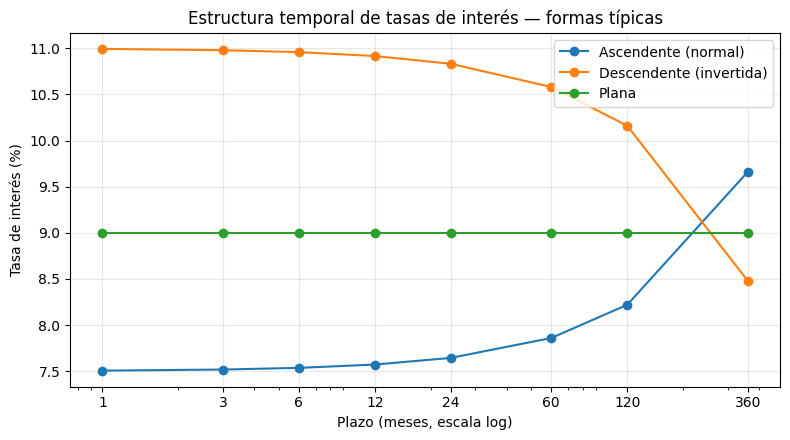

,Plazo (meses),Ascendente (normal),Descendente (invertida),Plana
0,1,7.510000,10.990000,9.000000
1,3,7.520000,10.980000,9.000000
2,6,7.540000,10.960000,9.000000
3,12,7.570000,10.920000,9.000000
4,24,7.640000,10.830000,9.000000
5,60,7.860000,10.580000,9.000000
6,120,8.220000,10.160000,9.000000
7,360,9.660000,8.480000,9.000000


In [10]:
plazos_meses = np.array([1, 3, 6, 12, 24, 60, 120, 360])

curvas = {
    "Ascendente (normal)":   0.075 + 0.00006 * plazos_meses,
    "Descendente (invertida)": 0.11 - 0.00007 * plazos_meses,
    "Plana": np.full_like(plazos_meses, 0.09, dtype=float),
}

fig, ax = plt.subplots()
for nombre, tasas in curvas.items():
    ax.plot(plazos_meses, tasas * 100, marker="o", label=nombre)

ax.set_xscale("log")
ax.set_xticks(plazos_meses)
ax.set_xticklabels(plazos_meses)
ax.set_xlabel("Plazo (meses, escala log)")
ax.set_ylabel("Tasa de interés (%)")
ax.set_title("Estructura temporal de tasas de interés — formas típicas")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"Plazo (meses)": plazos_meses, **{k: (v * 100).round(2) for k, v in curvas.items()}})


## Resumen de funciones del notebook

| Función | Uso |
|---|---|
| `construir_tasa_interes(...)` | Descompone/arma una tasa nominal por componentes de riesgo |
| `sensibilidad_rating(...)` | Compara la tasa cotizada según el riesgo de crédito de la contraparte |
| `tasa_real_exacta(i, π)` / `tasa_real_aproximada(i, π)` | Ecuación de Fisher exacta y aproximada |
| `tasa_nominal_exacta(r, π)` | Despeje de Fisher para obtener la tasa nominal |
| `convertir_tasa_proporcional(i_anual, m)` | Tasa periódica proporcional a partir de una tasa anual |
| `tasa_efectiva_simple(i, t)` / `tasa_efectiva_compuesta(i, t)` | Tasa efectivamente ganada/pagada |

## Ejercicios propuestos

1. Una empresa exportadora recibe cotizaciones de crédito en MXN (14.5% nominal,
   inflación esperada 4.8%) y en USD (7.2% nominal, inflación esperada 2.6%). ¿Cuál
   tasa real conviene más? ¿Qué otros riesgos (cambiario, de crédito) deberían
   incorporarse a la decisión?
2. Construye la tasa de descuento (costo de capital) para valuar un proyecto de
   inversión de una PyME con rating crediticio "B", plazo de 7 años y baja liquidez del
   instrumento de deuda. Usa `construir_tasa_interes`.
3. Con datos públicos de tu banco central, arma tu propia curva de rendimiento y
   clasifica su forma (ascendente, descendente o plana). ¿Qué implica para las
   expectativas de la economía?
